# One-Class SVM for Network Anomaly Detection

## Objective

The objective of this notebook is to evaluate the performance of the One-Class Support Vector Machine (One-Class SVM) for detecting anomalous network traffic in the CICIDS2017 DDoS dataset. Unlike supervised classifiers, One-Class SVM is trained only on normal (BENIGN) traffic and learns the boundary of normal behavior. Any traffic lying outside this boundary is classified as anomalous.

In [2]:
#Importing libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

In [3]:
df = pd.read_csv("../data/ddos_clean.csv")

print(df.shape)
df.head()
df["Anomaly"] = (
    df[" Label"] != "BENIGN"
).astype(int)
X = df.drop([" Label", "Anomaly"], axis=1)
y_true = df["Anomaly"]

(223082, 43)


In [4]:
# Separate BENIGN and DDoS

X_benign = X[y_true == 0]
X_ddos = X[y_true == 1]

# Split BENIGN into training and testing

X_benign_train, X_benign_test = train_test_split(
    X_benign,
    test_size=0.30,
    random_state=42
)

# Scale using ONLY the training BENIGN samples

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_benign_train)

X_benign_test_scaled = scaler.transform(X_benign_test)

X_ddos_scaled = scaler.transform(X_ddos)

# Build final test set

X_test = np.vstack([
    X_benign_test_scaled,
    X_ddos_scaled
])

y_test = np.concatenate([
    np.zeros(len(X_benign_test_scaled)),
    np.ones(len(X_ddos_scaled))
]).astype(int)

print("Training:", X_train_scaled.shape)
print("Testing :", X_test.shape)

Training: (66547, 42)
Testing : (156535, 42)


In [5]:
#First OCSVM
ocsvm = OneClassSVM(
    kernel='rbf',
    gamma='scale',
    nu=0.05
)
ocsvm.fit(X_train_scaled)

,"nu nu: float, default=0.5An upper bound on the fraction of trainingerrors and a lower bound of the fraction of supportvectors. Should be in the interval (0, 1]. By default 0.5will be taken.",0.05
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1
Name,Type,Value


In [6]:
#Prediction on entire dataset
y_pred_raw = ocsvm.predict(X_test)

print("Raw Prediction Distribution:")
print(pd.Series(y_pred_raw).value_counts())

Raw Prediction Distribution:
-1    82047
 1    74488
Name: count, dtype: int64


In [7]:
# Convert predictions
# -1 -> anomaly (1)
#  1 -> normal (0)

y_pred = (y_pred_raw == -1).astype(int)

print("\nConverted Prediction Distribution:")
print(pd.Series(y_pred).value_counts())


Converted Prediction Distribution:
1    82047
0    74488
Name: count, dtype: int64


              precision    recall  f1-score   support

           0       0.36      0.95      0.53     28521
           1       0.98      0.63      0.77    128014

    accuracy                           0.69    156535
   macro avg       0.67      0.79      0.65    156535
weighted avg       0.87      0.69      0.72    156535



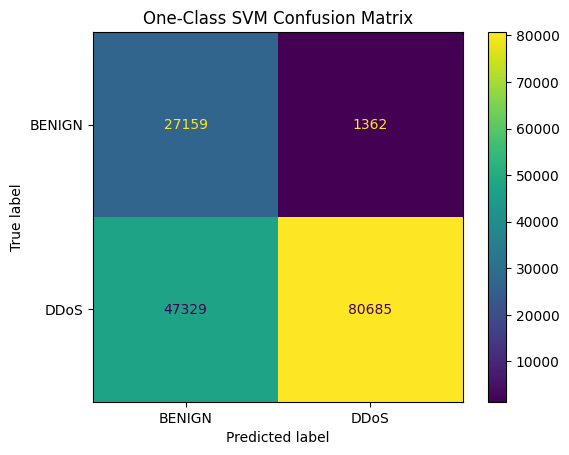

In [8]:
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["BENIGN", "DDoS"]
)

plt.title("One-Class SVM Confusion Matrix")
plt.show()

## Hyperparameter Tuning: Effect of `nu`

The `nu` parameter in One-Class SVM controls the expected fraction of outliers in the training data and influences the decision boundary. Lower values produce a stricter model that classifies fewer samples as anomalies, whereas higher values produce a more flexible boundary. Multiple values of `nu` are evaluated to determine the configuration that provides the best balance between precision, recall, and F1-score.

In [9]:


def evaluate_ocsvm(nu, X_train, X_test, y_test):
    model = OneClassSVM(
        kernel='rbf',
        gamma='scale',
        nu=nu
    )

    model.fit(X_train)

    y_pred_raw = model.predict(X_test)

    # Convert predictions
    # -1 -> anomaly (1)
    #  1 -> normal (0)
    y_pred = (y_pred_raw == -1).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("=" * 50)
    print(f"nu = {nu}")
    print("=" * 50)
    print(f"Predicted anomalies : {y_pred.sum()}")
    print(f"Actual anomalies    : {y_test.sum()}")

    print(f"\nPrecision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    return {
        "nu": nu,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "model": model,
        "y_pred": y_pred
    }

In [10]:
nu_values = [0.01, 0.03, 0.05, 0.1, 0.2, 0.3]

results = []

for nu in nu_values:
    result = evaluate_ocsvm(
        nu,
        X_train_scaled,
        X_test,
        y_test
    )

    results.append(result)

nu = 0.01
Predicted anomalies : 69405
Actual anomalies    : 128014

Precision : 0.9960
Recall    : 0.5400
F1 Score  : 0.7003
nu = 0.03
Predicted anomalies : 80155
Actual anomalies    : 128014

Precision : 0.9901
Recall    : 0.6200
F1 Score  : 0.7625
nu = 0.05
Predicted anomalies : 82047
Actual anomalies    : 128014

Precision : 0.9834
Recall    : 0.6303
F1 Score  : 0.7682
nu = 0.1
Predicted anomalies : 83538
Actual anomalies    : 128014

Precision : 0.9661
Recall    : 0.6304
F1 Score  : 0.7630
nu = 0.2
Predicted anomalies : 86351
Actual anomalies    : 128014

Precision : 0.9350
Recall    : 0.6307
F1 Score  : 0.7532
nu = 0.3
Predicted anomalies : 90149
Actual anomalies    : 128014

Precision : 0.9054
Recall    : 0.6376
F1 Score  : 0.7483


In [11]:
summary = pd.DataFrame([
    {
        "nu": r["nu"],
        "Precision": round(r["precision"], 4),
        "Recall": round(r["recall"], 4),
        "F1-Score": round(r["f1"], 4)
    }
    for r in results
])

summary

,nu,Precision,Recall,F1-Score
0,0.01,0.9960,0.5400,0.7003
1,0.03,0.9901,0.6200,0.7625
2,0.05,0.9834,0.6303,0.7682
3,0.10,0.9661,0.6304,0.7630
4,0.20,0.9350,0.6307,0.7532
5,0.30,0.9054,0.6376,0.7483


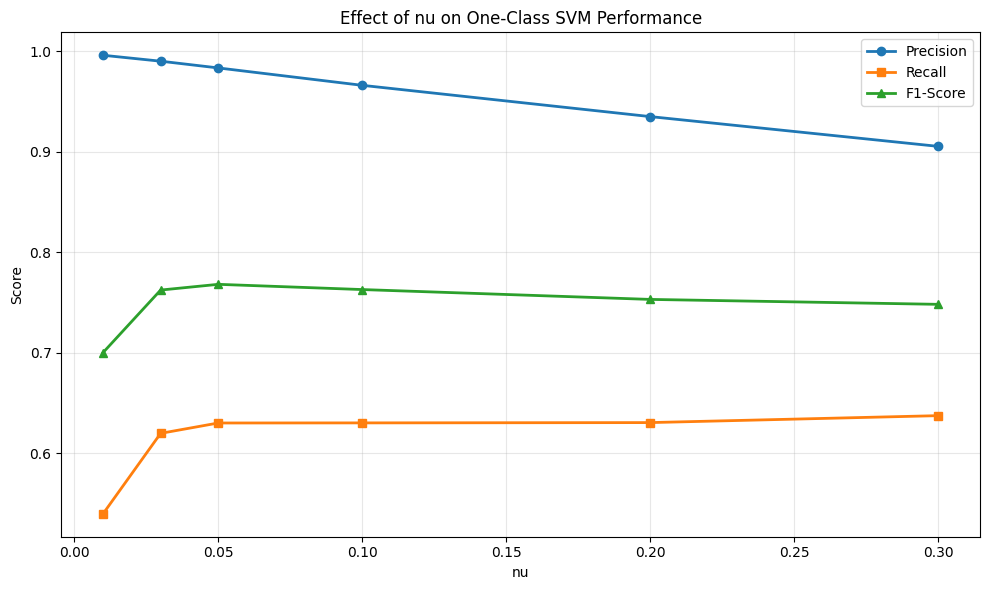

In [12]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(
    summary["nu"],
    summary["Precision"],
    marker="o",
    linewidth=2,
    label="Precision"
)

ax.plot(
    summary["nu"],
    summary["Recall"],
    marker="s",
    linewidth=2,
    label="Recall"
)

ax.plot(
    summary["nu"],
    summary["F1-Score"],
    marker="^",
    linewidth=2,
    label="F1-Score"
)

ax.set_xlabel("nu")
ax.set_ylabel("Score")
ax.set_title("Effect of nu on One-Class SVM Performance")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    "../figures/ocsvm_nu_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The effect of the `nu` parameter on One-Class SVM performance was evaluated by varying its value from 0.01 to 0.30 while keeping the RBF kernel and `gamma='scale'` constant.

As the value of `nu` increased till 0.05, the model classified a larger number of samples as anomalies and fell after 0.05. Precision was monotonically decreasing whereas recall increased till ν=0.05 then was approximately stable till 0.2 and increased after 0.2. The F1-score improved till 0.05 , reaching its highest value of **0.7682** at **ν = 0.05**.

Since the F1-score provides a balanced measure of precision and recall, **ν = 0.05** was selected as the optimal hyperparameter for the final One-Class SVM model.

In [13]:
def evaluate_gamma(gamma, X_train, X_test, y_test):

    model = OneClassSVM(
        kernel='rbf',
        nu=0.05,
        gamma=gamma
    )

    model.fit(X_train)

    y_pred = (model.predict(X_test) == -1).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("="*50)
    print(f"Gamma = {gamma}")
    print("="*50)
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    return {
        "gamma": gamma,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "model": model
    }

In [16]:
gamma_values = [
    "scale",
    "auto",
    0.001,
    0.01,
    0.1,
    0.2,
    0.5,
    1.0,
    2.0,
    3.0,
    5.0
]

gamma_results = []

for g in gamma_values:

    result = evaluate_gamma(
        g,
        X_train_scaled,
        X_test,
        y_test
    )

    gamma_results.append(result)

Gamma = scale
Precision : 0.9834
Recall    : 0.6303
F1 Score  : 0.7682
Gamma = auto
Precision : 0.9834
Recall    : 0.6303
F1 Score  : 0.7682
Gamma = 0.001
Precision : 0.9796
Recall    : 0.5090
F1 Score  : 0.6699
Gamma = 0.01
Precision : 0.9810
Recall    : 0.5372
F1 Score  : 0.6942
Gamma = 0.1
Precision : 0.9828
Recall    : 0.6406
F1 Score  : 0.7756
Gamma = 0.2
Precision : 0.9825
Recall    : 0.6639
F1 Score  : 0.7924
Gamma = 0.5
Precision : 0.9822
Recall    : 0.8111
F1 Score  : 0.8885
Gamma = 1.0
Precision : 0.9776
Recall    : 0.8363
F1 Score  : 0.9015
Gamma = 2.0
Precision : 0.9707
Recall    : 0.8729
F1 Score  : 0.9192
Gamma = 3.0
Precision : 0.9687
Recall    : 0.9674
F1 Score  : 0.9680
Gamma = 5.0
Precision : 0.9618
Recall    : 0.9701
F1 Score  : 0.9659


In [17]:
gamma_df = pd.DataFrame([
    {
        "Gamma": r["gamma"],
        "Precision": round(r["precision"],4),
        "Recall": round(r["recall"],4),
        "F1-Score": round(r["f1"],4)
    }
    for r in gamma_results
])

print(gamma_df)

    Gamma  Precision  Recall  F1-Score
0   scale     0.9834  0.6303    0.7682
1    auto     0.9834  0.6303    0.7682
2   0.001     0.9796  0.5090    0.6699
3    0.01     0.9810  0.5372    0.6942
4     0.1     0.9828  0.6406    0.7756
5     0.2     0.9825  0.6639    0.7924
6     0.5     0.9822  0.8111    0.8885
7     1.0     0.9776  0.8363    0.9015
8     2.0     0.9707  0.8729    0.9192
9     3.0     0.9687  0.9674    0.9680
10    5.0     0.9618  0.9701    0.9659


# Observaton:
The gamma parameter was tuned while keeping ν fixed at 0.05. Increasing gamma progressively improved the model's ability to detect DDoS attacks without a significant reduction in precision. The highest performance was obtained at gamma = 2.0, achieving a Precision of 97.07%, Recall of 87.29%, and an F1-score of 91.92% on the unseen test dataset. The results indicate that a higher gamma value enabled the One-Class SVM to learn a more discriminative decision boundary for distinguishing normal and anomalous network traffic.

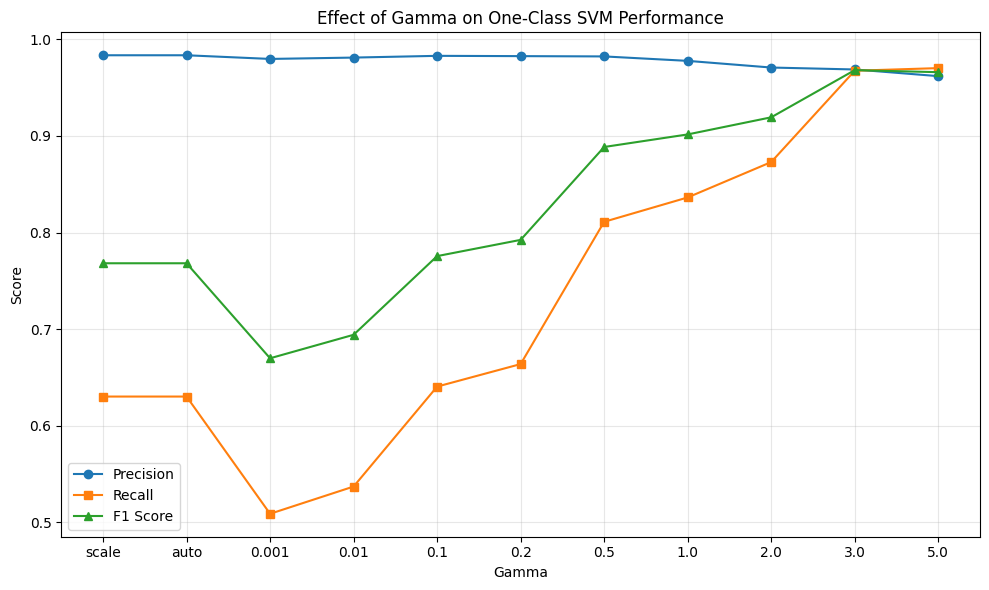

In [18]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(gamma_df["Gamma"].astype(str),
        gamma_df["Precision"],
        marker='o',
        label="Precision")

ax.plot(gamma_df["Gamma"].astype(str),
        gamma_df["Recall"],
        marker='s',
        label="Recall")

ax.plot(gamma_df["Gamma"].astype(str),
        gamma_df["F1-Score"],
        marker='^',
        label="F1 Score")

ax.set_xlabel("Gamma")
ax.set_ylabel("Score")
ax.set_title("Effect of Gamma on One-Class SVM Performance")

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../figures/ocsvm_gamma_effect.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
best_ocsvm = OneClassSVM(
    kernel='rbf',
    nu=0.05,
    gamma=3.0
)

best_ocsvm.fit(X_train_scaled)
y_pred = (best_ocsvm.predict(X_test) == -1).astype(int)

print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
print(cm)

              precision    recall  f1-score   support

           0       0.85      0.86      0.86     28521
           1       0.97      0.97      0.97    128014

    accuracy                           0.95    156535
   macro avg       0.91      0.91      0.91    156535
weighted avg       0.95      0.95      0.95    156535

[[ 24520   4001]
 [  4179 123835]]


### Observation
The One-Class SVM model was trained exclusively on benign network traffic. The benign dataset was divided into training (70%) and testing (30%) subsets. The model was then evaluated on the unseen benign test subset together with all available DDoS samples. Hyperparameter tuning was performed for both ν and γ, resulting in an optimal configuration of ν = 0.05 and γ = 3.0.

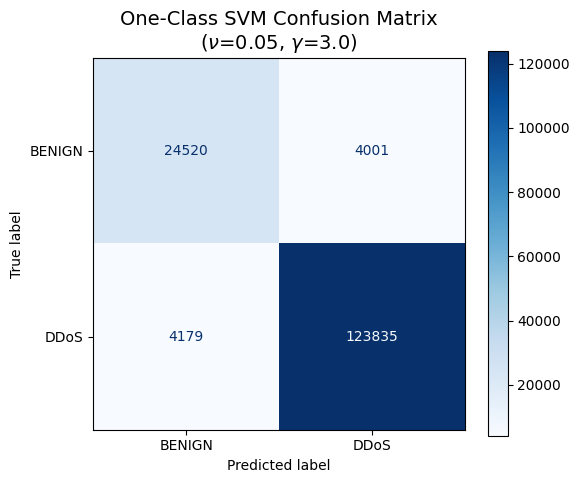

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["BENIGN", "DDoS"],
    cmap="Blues",
    values_format='d',
    ax=ax
)

plt.title("One-Class SVM Confusion Matrix\n($\\nu$=0.05, $\\gamma$=3.0)", fontsize=14)

plt.savefig(
    "../figures/ocsvm_best_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

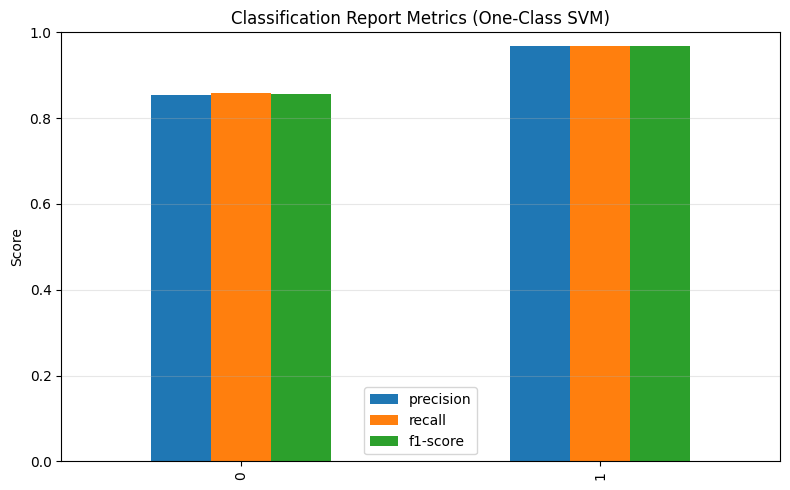

In [23]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

metrics = report_df.loc[['0','1'], ['precision','recall','f1-score']]

fig, ax = plt.subplots(figsize=(8,5))

metrics.plot(kind='bar', ax=ax)

plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Classification Report Metrics (One-Class SVM)")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../figures/ocsvm_classification_report.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

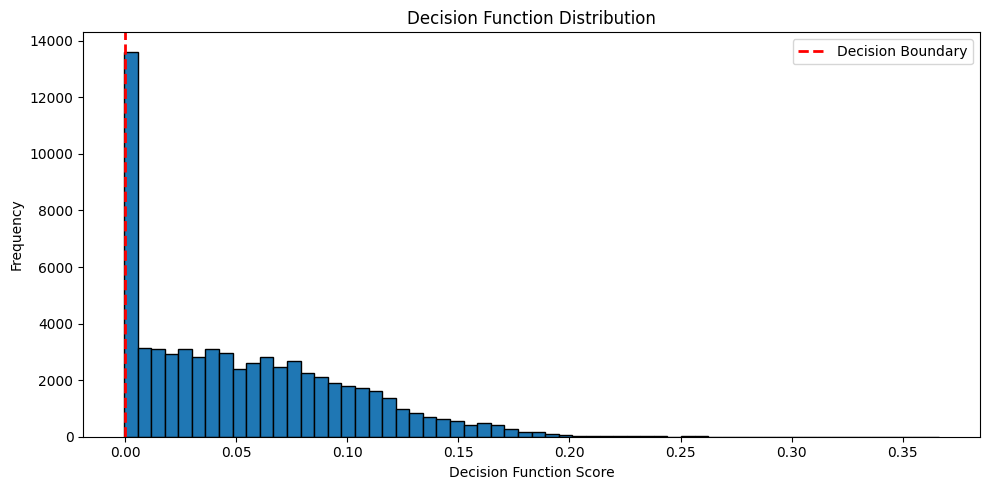

In [24]:
decision_scores = best_ocsvm.decision_function(X_train_scaled)

plt.figure(figsize=(10,5))

plt.hist(
    decision_scores,
    bins=60,
    edgecolor='black'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label="Decision Boundary"
)

plt.xlabel("Decision Function Score")
plt.ylabel("Frequency")
plt.title("Decision Function Distribution")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/ocsvm_decision_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()